# AMICA: Improving Cell Type Annotation Granularity

This notebook demonstrates the progress of the AMICA (Automated Mapping and Identification of Cell Annotations) agent in improving the granularity of cell type annotations from scientific literature.

## 1. The Problem: Inconsistent Annotations

Manually curated cell type annotations often vary in specificity. Authors might use general terms (e.g., "endothelial cell") when a more precise term exists (e.g., "endothelial cell of arteriole"). This inconsistency makes large-scale data integration and analysis challenging.

**Goal:** Use an AI agent (AMICA) to automatically suggest more granular and contextually appropriate ontology terms based on information extracted from the source publication.

## 2. Setup and Data Loading

First, let's install the necessary libraries and load the results from all the `groundings.tsv` files generated by the annotation pipeline.

In [1]:
%pip install pandas oaklib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
from pathlib import Path

# Set the display option to show full content of columns
pd.set_option('display.max_colwidth', None)

output_dir = Path('../cellsem_agent/graphs/cxg_annotate/resources/output/')
grounding_files = list(output_dir.glob('**/groundings.tsv'))

all_data = []
for f in grounding_files:
    try:
        df = pd.read_csv(f, sep='\t')
        all_data.append(df)
    except Exception as e:
        print(f"Could not read {f}: {e}")

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Successfully loaded {len(combined_df)} records from {len(grounding_files)} datasets.")
else:
    print("No grounding files found or loaded.")

Successfully loaded 855 records from 29 datasets.


## 3. Improved Granularity Examples 

Improved granularity cases is when AMICA provides a more specific ontology term than the author's original annotation. We can identify these cases by checking if the author's term is an **ancestor** of the agent's term in the Cell Ontology.

For example, `cell` (CL:0000000) is an ancestor of `fibroblast` (CL:0000057). If the author mapped to `cell` and the agent mapped to `fibroblast`, it's an improvement.

In [8]:
import json
from oaklib import get_adapter
from pathlib import Path

try:
    cl_adapter = get_adapter("ols:cl")
    print("Successfully connected to Cell Ontology.")
except Exception as e:
    cl_adapter = None
    print(f"Could not connect to Cell Ontology via OLS: {e}")

improved_examples = []
if cl_adapter and 'combined_df' in locals():
    for _, row in combined_df.iterrows():
        author_id = str(row.get('cl_id', ''))
        agent_id = str(row.get('grounding_cl_id', ''))

        if author_id and agent_id and author_id != agent_id and 'CL:' in author_id and 'CL:' in agent_id:
            try:
                # Check if the author's term is an ancestor of the agent's more specific term
                ancestors = cl_adapter.ancestors(agent_id, predicates=['rdfs:subClassOf', 'BFO:0000050'])
                if author_id in ancestors:
                    # Safely parse the enrichment column to get the full_name
                    full_name = "Not available"
                    try:
                        # The enrichment data is stored as a string representation of a dictionary.
                        # We need to convert it to a proper dictionary.
                        # Using eval is a direct way, but be cautious with untrusted data.
                        # A safer method is using json.loads after replacing single quotes.
                        enrichment_str = row['enrichment']
                        if isinstance(enrichment_str, str):
                            enrichment_data = json.loads(enrichment_str.replace("'", "\""))
                            full_name = enrichment_data.get('full_name', 'Not available')
                    except (json.JSONDecodeError, TypeError, SyntaxError):
                        # Handles cases where the string is not a valid dict or is NaN
                        pass

                    improved_examples.append({
                        "Annotation": row['annotation_text'],
                        "Full Name (from paper)": full_name,
                        "Author Mapping": f"{row['cl_label']} ({author_id})",
                        "Agent's Granular Mapping": f"{row['grounding_cl_label']} ({agent_id})",
                        "Dataset": Path(row['dataset_name']).name
                    })
            except Exception as e:
                # OLS can be flaky, so we continue on error
                pass

if improved_examples:
    improved_df = pd.DataFrame(improved_examples)
    # Reorder columns to be more intuitive
    improved_df = improved_df[[
        "Annotation",
        "Full Name (from paper)",
        "Author Mapping",
        "Agent's Granular Mapping",
        "Dataset"
    ]]
    display(improved_df)
else:
    print("No clear examples of improved granularity were found.")

Successfully connected to Cell Ontology.


,Annotation,Full Name (from paper),Author Mapping,Agent's Granular Mapping,Dataset
0,Prolif-Mac,Not available,macrophage (CL:0000235),cycling macrophage (CL:4033076),1873a18a-66fd-4a4d-8277-a872c93f5b59_cxg_dataset_unique
1,IC-PC,intercalated cell–principal cell,columnar/cuboidal epithelial cell (CL:0000075),renal intercalated cell (CL:0005010),f801b7a9-80a6-4d09-9161-71474deb58ae_cxg_dataset_unique
2,Afferent / Efferent Arteriole Endothelial Cell,endothelial cell of the afferent/efferent arterioles (EC-AEA),endothelial cell (CL:0000115),endothelial cell of arteriole (CL:1000412),0b75c598-0893-4216-afe8-5414cab7739d_cxg_dataset_unique
3,Ascending Vasa Recta Endothelial Cell,ascending vasa recta endothelial cell,endothelial cell (CL:0000115),vasa recta ascending limb cell (CL:1001131),0b75c598-0893-4216-afe8-5414cab7739d_cxg_dataset_unique
4,C-PC,cortical principal cell,kidney collecting duct principal cell (CL:1001431),kidney cortex collecting duct principal cell (CL:1000714),0b75c598-0893-4216-afe8-5414cab7739d_cxg_dataset_unique
...,...,...,...,...,...
123,OFFx,Not available,OFF-bipolar cell (CL:0000750),OFFx cell (CL:4033036),8623d55f-d91c-41c2-ae68-ed2072fd268d_cxg_dataset_unique
124,RB1,Not available,ON-bipolar cell (CL:0000749),rod bipolar cell (CL:0000751),8623d55f-d91c-41c2-ae68-ed2072fd268d_cxg_dataset_unique
125,B cell cycling,Not available,B cell (CL:0000236),cycling B cell (CL:4033068),2872f4b0-b171-46e2-abc6-befcf6de6306_cxg_dataset_unique
126,cycling DCs,Not available,dendritic cell (CL:0000451),cycling dendritic cell (CL:4033070),2872f4b0-b171-46e2-abc6-befcf6de6306_cxg_dataset_unique


## 4. Analysis: Where Can AMICA Improve?

 The primary area for improvement is **Regressions**: cases when the agent suggests a *less* specific term than the author. This is tested by checking whether the agent's CL term is an anscestor of the author's CL term.

To improve the agent's performance, test with:
- Tissue context 
- Species context (very common with immune cells)
- Pre-process author's datasets to filter cases where the 'author-defined cell set' (the text label) represents a different, broader concept than the 'CL-defined cell set'. 

(Note: Cases where the agent returns `NO MATCH found` are not treated as failures. Instead, they potential missing CL terms.)

In [6]:
regressions = []

if cl_adapter and 'combined_df' in locals():
    for _, row in combined_df.iterrows():
        author_id = str(row.get('cl_id', ''))
        agent_id = str(row.get('grounding_cl_id', ''))
            
        # Case: Agent provided a less granular term (regression)
        if author_id and agent_id and author_id != agent_id and 'CL:' in author_id and 'CL:' in agent_id:
            try:
                # Get the ancestors of the AUTHOR's term
                ancestors = cl_adapter.ancestors(author_id)
                # Check if the AGENT's term is in the author's ancestor list
                if agent_id in ancestors:
                    regressions.append({
                        'Annotation': row['annotation_text'],
                        'Author Granular Mapping': f"{row['cl_label']} ({author_id})",
                        'Agent\'s General Mapping': f"{row['grounding_cl_label']} ({agent_id})",
                        'Dataset': Path(row['dataset_name']).name
                    })
            except Exception as e:
                # OLS can be flaky, so we continue on error
                pass

print("--- Limitations: Agent Returned a Less Specific Term ---")
if regressions:
    regressions_df = pd.DataFrame(regressions)
    display(regressions_df)
else:
    print("No clear examples of regressions were found.")

--- Limitations: Agent Returned a Less Specific Term ---


,Annotation,Author Granular Mapping,Agent's General Mapping,Dataset
0,retinal bipolar neuron type A,ON-bipolar cell (CL:0000749),retinal bipolar neuron (CL:0000748),d5c67a4e-a8d9-456d-a273-fa01adb1b308_cxg_dataset_unique
1,retinal bipolar neuron type B,OFF-bipolar cell (CL:0000750),retinal bipolar neuron (CL:0000748),d5c67a4e-a8d9-456d-a273-fa01adb1b308_cxg_dataset_unique
2,retinal bipolar neuron type C,ON-bipolar cell (CL:0000749),retinal bipolar neuron (CL:0000748),d5c67a4e-a8d9-456d-a273-fa01adb1b308_cxg_dataset_unique
3,retinal bipolar neuron type D,ON-bipolar cell (CL:0000749),retinal bipolar neuron (CL:0000748),d5c67a4e-a8d9-456d-a273-fa01adb1b308_cxg_dataset_unique
4,AntiB,plasma cell (CL:0000786),antibody secreting cell (CL:0000946),1873a18a-66fd-4a4d-8277-a872c93f5b59_cxg_dataset_unique
...,...,...,...,...
172,basal2,basal cell of epidermis (CL:0002187),basal cell (CL:0000646),f512b8b6-369d-4a85-a695-116e0806857f_cxg_dataset_unique
173,spinous,spinous cell of epidermis (CL:0000649),spinous cell (CL:4052060),f512b8b6-369d-4a85-a695-116e0806857f_cxg_dataset_unique
174,Macrophage,colon macrophage (CL:0009038),macrophage (CL:0000235),2872f4b0-b171-46e2-abc6-befcf6de6306_cxg_dataset_unique
175,acinar,pancreatic acinar cell (CL:0002064),acinar cell (CL:0000622),37b21763-7f0f-41ae-9001-60bad6e2841d_cxg_dataset_unique


## 5. Overall Performance Statistics

To get a quantitative measure of AMICA's performance, we can categorize every annotation in the dataset into one of the following buckets:

- **Improved Granularity**: The agent provided a more specific term (a subclass or `part_of` the author's term).
- **Exact Match**: The agent's term is identical to the author's term.
- **Regression**: The agent provided a less specific term (an ancestor of the author's term).
- **Other (unrelated)**: The agent's term and the author's term are unrelated hierarchically.
- **No Match Found**: The agent could not find a grounding for the annotation. Potential new CL terms.

---

### Note on “Regression”

The current **20.7% regression rate is inflated** by many *false regressions* caused by inconsistencies in the source annotations rather than agent errors.

**Example:**  
In one dataset, the author's 'defined cell set' such as **“Lymphoid_T/NK”** are broad categories but are linked to many highly specific CL terms (e.g., *natural killer cell*, *effector memory T cell*, *activated CD8+ αβ T cell*).

- **Agent’s mapping:** Correctly assigns the logical parent term **CL:0000542 (lymphocyte)**.  
- **Analysis outcome:** Incorrectly flags these as regressions because it compares the agent's CL term to each specific author mapping.

To better measure true agent performance, the author's datasets will be pre-processed in the future to filter cases where the 'author-defined cell set' (the text label) represents a different, broader concept than the 'CL-defined cell set'.

---

This analysis provides a high-level overview of how often the agent adds value, stays consistent, or requires further refinement.

In [9]:
import numpy as np

stats = {
    'improved_granularity': 0,
    'exact_match': 0,
    'regression': 0,
    'other': 0,
    'no_match': 0,
    'total': 0
}

if cl_adapter and 'combined_df' in locals():
    total_records = len(combined_df)
    stats['total'] = total_records

    for _, row in combined_df.iterrows():
        author_id = str(row.get('cl_id', ''))
        agent_id = str(row.get('grounding_cl_id', ''))

        # Category: No Match
        if not agent_id or agent_id == 'nan' or 'NO MATCH' in agent_id:
            stats['no_match'] += 1
            continue
        
        # Ensure both are valid CL terms for comparison
        if not author_id or author_id == 'nan' or 'CL:' not in author_id or 'CL:' not in agent_id:
            # If author_id is invalid, we can't compare.
            # We could count this in a separate category, but for now we'll skip comparison.
            continue

        # Category: Exact Match
        if author_id == agent_id:
            stats['exact_match'] += 1
            continue

        try:
            # Category: Improved Granularity
            # Check if author_id is an ancestor of agent_id (is_a or part_of)
            agent_ancestors = cl_adapter.ancestors(agent_id, predicates=['rdfs:subClassOf', 'BFO:0000050'])
            if author_id in agent_ancestors:
                stats['improved_granularity'] += 1
                continue

            # Category: Regression
            # Check if agent_id is an ancestor of author_id
            author_ancestors = cl_adapter.ancestors(author_id, predicates=['rdfs:subClassOf'])
            if agent_id in author_ancestors:
                stats['regression'] += 1
                continue
            
            # If none of the above, it's an 'other' relationship
            stats['other'] += 1

        except Exception as e:
            # OLS can be flaky, so we count errors as 'other' for now
            # print(f"Could not process comparison for {author_id} and {agent_id}: {e}")
            stats['other'] += 1


# Create a DataFrame for displaying the statistics
stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['Count'])
stats_df['Percentage'] = (stats_df['Count'] / stats_df.loc['total', 'Count'] * 100).round(2).astype(str) + '%'

# Remove the total from the percentage calculation display
stats_df.loc['total', 'Percentage'] = ''

display(stats_df)

,Count,Percentage
improved_granularity,128,14.97%
exact_match,401,46.9%
regression,177,20.7%
other,77,9.01%
no_match,56,6.55%
total,855,


## 6. In-depth Analysis of Regressions and "Other" Mismatches (Filtered)

To better understand the agent's performance, we can apply the same filtering logic used in the `filtered_data_stats.py` script. This involves excluding annotations that were originally labeled as 'broad term' or 'overlaps' in the ground truth data. By removing this noise, we can get a clearer picture of true regressions and other types of mismatches.

### Filtered Regression and "Other" Cases
First, we'll define the function to read the ground truth data and then process the annotations to find the specific examples for each category.

In [3]:
# --- CELL 1: Imports & Setup ---
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from oaklib import get_adapter

# Initialize Ontology Adapter
# (This might take a moment to connect)
try:
    cl_adapter = get_adapter("ols:cl")
    print("✅ Connected to Cell Ontology (OLS).")
except Exception as e:
    print(f"⚠️ Could not connect to OLS: {e}")
    cl_adapter = None

/Users/ce12/Documents/GitHub/cellsem-agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Connected to Cell Ontology (OLS).


/Users/ce12/Documents/GitHub/cellsem-agent/.venv/lib/python3.12/site-packages/eutils/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
# --- CELL 2: Configuration ---

# Adjust this path to point to your 'resources' folder relative to this notebook
# Based on your previous messages, it seems to be here:
BASE_PATH = Path("../cellsem_agent/graphs/cxg_annotate/resources")

INPUT_DIR = BASE_PATH / "input/matrix_outputs_30"
OUTPUT_DIR = BASE_PATH / "output"

print(f"Input Directory: {INPUT_DIR.resolve()}")
print(f"Output Directory: {OUTPUT_DIR.resolve()}")

# Verification check
if not INPUT_DIR.exists() or not OUTPUT_DIR.exists():
    print("⚠️ WARNING: One or more directories do not exist. Please check the path.")

Input Directory: /Users/ce12/Documents/GitHub/cellsem-agent/cellsem_agent/graphs/cxg_annotate/resources/input/matrix_outputs_30
Output Directory: /Users/ce12/Documents/GitHub/cellsem-agent/cellsem_agent/graphs/cxg_annotate/resources/output


In [9]:
# --- CELL 3: Helper Functions ---

def get_match_type_map(dataset_folder_name):
    """
    Reads the ground truth input file to get 'match_type' for each (text, id) pair.
    Handles column mapping (author_cell_type -> annotation_text).
    """
    input_path = INPUT_DIR / f"{dataset_folder_name}.tsv"
    if not input_path.exists():
        input_path = INPUT_DIR / f"{dataset_folder_name}.csv"
    
    if input_path.exists():
        try:
            df = pd.read_csv(input_path, sep='\t')
            
            # 1. Normalize column names (Input specific -> Standard)
            if 'author_cell_type' in df.columns: df['annotation_text'] = df['author_cell_type']
            if 'CL_ID' in df.columns: df['cl_id'] = df['CL_ID']
            
            # 2. Check if required columns exist
            if 'match_type' not in df.columns: return {}

            # 3. Clean and Normalize values
            df['cl_id'] = df['cl_id'].astype(str).str.strip()
            df['annotation_text'] = df['annotation_text'].astype(str).str.strip()
            # Convert "Broad Term" -> "broad_term"
            df['match_type'] = df['match_type'].astype(str).str.lower().str.replace(' ', '_')
            
            # Return Dictionary: {(text, id) : match_type}
            return df.set_index(['annotation_text', 'cl_id'])['match_type'].to_dict()
        except Exception as e:
            # print(f"Error reading input for {dataset_folder_name}: {e}")
            return {}
    return {}

def calculate_stats(df, match_type_map, filter_noisy=False):
    """
    Calculates performance stats. 
    If filter_noisy=True, it skips 'broad_term' and 'overlaps'.
    """
    stats = {"Improved": 0, "Exact": 0, "Regression": 0, "No Match": 0, "Other": 0, "Total": 0}
    
    for _, row in df.iterrows():
        author_cl = str(row.get('cl_id', '')).strip()
        # Get raw agent string to check for 'NO MATCH' text
        agent_raw = str(row.get('grounding_cl_id', '')).strip()
        text = str(row.get('annotation_text', '')).strip()
        
        # Skip invalid author entries
        if not author_cl or author_cl.lower() == 'nan': continue

        # --- FILTERING STEP ---
        match_type = match_type_map.get((text, author_cl), "unknown")
        
        if filter_noisy:
            if match_type in ['broad_term', 'overlaps']:
                continue # Skip this row completely
            
        stats["Total"] += 1

        # --- CATEGORIZATION ---
        
        # 1. No Match Found
        if not agent_raw or agent_raw.lower() in ['nan', 'none'] or 'no match' in agent_raw.lower():
            stats["No Match"] += 1
            continue
            
        # 2. Exact Match
        if author_cl == agent_raw:
            stats["Exact"] += 1
            continue
            
        # 3. Ontology Checks
        try:
            # Improvement (Agent is Child OR Part_of Author)
            if cl_adapter and author_cl in cl_adapter.ancestors(agent_raw, predicates=['rdfs:subClassOf', 'BFO:0000050']):
                stats["Improved"] += 1
                continue
            # Regression (Agent is Parent of Author - strict is_a)
            if cl_adapter and agent_raw in cl_adapter.ancestors(author_cl, predicates=['rdfs:subClassOf']):
                stats["Regression"] += 1
                continue
        except:
            pass
        
        # 4. Other
        stats["Other"] += 1
        
    return stats

In [10]:
# --- CELL 4: Main Analysis Loop ---

raw_results = []
clean_results = []

grounding_files = list(OUTPUT_DIR.glob('**/groundings.tsv'))
print(f"Found {len(grounding_files)} datasets. Processing...")

for file_path in grounding_files:
    dataset_name = file_path.parent.name
    try:
        df = pd.read_csv(file_path, sep='\t')
        mapping = get_match_type_map(dataset_name)
        
        # 1. Calculate RAW stats (All data, no filtering)
        raw = calculate_stats(df, mapping, filter_noisy=False)
        for cat, count in raw.items():
            if cat != "Total":
                raw_results.append({
                    "Dataset": dataset_name, 
                    "Category": cat, 
                    "Count": count, 
                    "Scope": "Raw (All Data)"
                })
        
        # 2. Calculate CLEAN stats (Filter out broad terms)
        clean = calculate_stats(df, mapping, filter_noisy=True)
        for cat, count in clean.items():
            if cat != "Total":
                clean_results.append({
                    "Dataset": dataset_name, 
                    "Category": cat, 
                    "Count": count, 
                    "Scope": "Cleaned (High Quality)"
                })
                
    except Exception as e:
        print(f"Error processing {dataset_name}: {e}")

print("✅ Analysis Complete.")

Found 29 datasets. Processing...
✅ Analysis Complete.
✅ Analysis Complete.


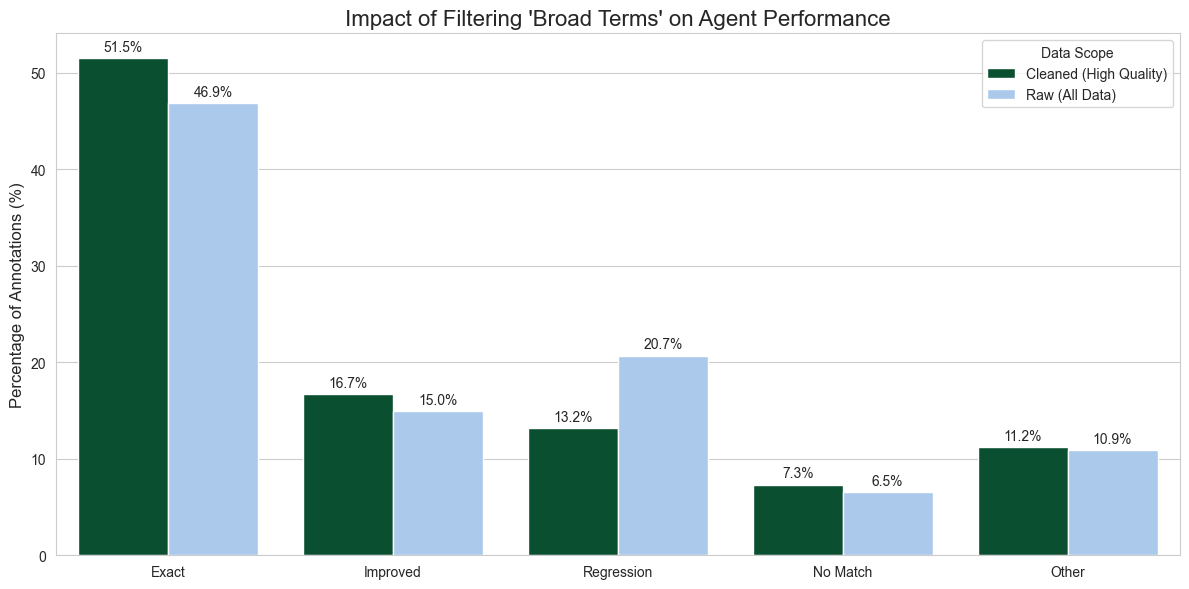


Summary Table (Aggregate Percentages):


Scope,Cleaned (High Quality),Raw (All Data)
Category,,
Exact,51.50%,46.90%
Improved,16.73%,14.97%
Regression,13.20%,20.70%
No Match,7.32%,6.55%
Other,11.24%,10.88%


In [11]:
# --- CELL 5: Visualization ---

import seaborn as sns

# Combine data
viz_df = pd.DataFrame(raw_results + clean_results)

# Group by Scope and Category to get aggregate sums
summary_df = viz_df.groupby(['Scope', 'Category'])['Count'].sum().reset_index()

# Calculate percentages based on the total for that Scope
total_raw = summary_df[summary_df['Scope'] == 'Raw (All Data)']['Count'].sum()
total_clean = summary_df[summary_df['Scope'] == 'Cleaned (High Quality)']['Count'].sum()

def get_pct(row):
    total = total_raw if row['Scope'] == 'Raw (All Data)' else total_clean
    return (row['Count'] / total) * 100

summary_df['Percentage'] = summary_df.apply(get_pct, axis=1)

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Custom order for logical flow
order = ["Exact", "Improved", "Regression", "No Match", "Other"]

# Create Bar Chart
ax = sns.barplot(
    data=summary_df, 
    x='Category', 
    y='Percentage', 
    hue='Scope', 
    order=order,
    palette={"Raw (All Data)": "#a1c9f4", "Cleaned (High Quality)": "#005a32"}
)

plt.title("Impact of Filtering 'Broad Terms' on Agent Performance", fontsize=16)
plt.ylabel("Percentage of Annotations (%)", fontsize=12)
plt.xlabel(None)
plt.legend(title="Data Scope")

# Add percentage text labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# --- TABLE DISPLAY ---
print("\nSummary Table (Aggregate Percentages):")
pivot_table = summary_df.pivot(index='Category', columns='Scope', values='Percentage').reindex(order)
display(pivot_table.style.format("{:.2f}%").background_gradient(cmap="Greens", axis=None))